# The rudimentary WCSPH acoustic core — explicit vs. Picard vs. JFNK, past the acoustic CFL

`JFNK_PLAN.md` Phase B built the smallest real *fluid* problem in this
codebase where an implicit acoustic solve pays off: continuity + isothermal
EOS + symmetric pressure force, with **every dissipation term at zero** — no
artificial viscosity, no physical viscosity, no free-surface treatment, no
particle shifting. It sits between the wave equation (`jfnk_solver_exploration.ipynb`
/ `waveCase_implicit_vs_explicit.ipynb`, one linear operator, static
neighbours) and the real `deltaSPH_step` acoustic subsystem (`JFNK_PLAN.md`
Phase C/D, needs one more JVP derivation) — a second validation rung, but a
genuinely nonlinear, moving-particle one this time.

**The hypothesis this notebook tests** (`JFNK_PLAN.md` Phase B, in the
user's own words): *"it should theoretically be feasible, with an implicit
solver of sufficient accuracy, to run the simulation without dissipation."*
Explicit WCSPH needs artificial viscosity/diffusion for numerical stability
in practice — is that a property of *explicit* time integration specifically,
or of weakly-compressible SPH in general? An L-stable implicit treatment of
the acoustic part damps exactly the high-frequency modes artificial
viscosity usually patches over; if that's sufficient on its own, a
well-converged (not the fixed-2-iteration Picard default) implicit solve
should stay bounded with every dissipation term at zero, at a `dt` set by
the *advective* CFL rather than the *acoustic* one — where the explicit
scheme (and, this notebook adds, the registry's own Picard default)
provably would not.

**Requires** the same environment as the wave-equation notebooks (`warp`
conda env, CUDA GPU or CPU fallback).

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import torch

import warp as wp
wp.init()

plt.rcParams['figure.figsize'] = (7, 4.5)
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

Warp 1.16.0 initialized:
   CUDA Toolkit 12.9, Driver 13.3
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 6000 Blackwell Workstation Edition" (95 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.16.0


## The rudimentary acoustic core

`warpSPH.schemes.acousticCore.f_acoustic_core` solves

$$
\frac{dx}{dt} = v, \qquad
\frac{d\rho}{dt} = -\rho\,\mathrm{Divergence}(v), \qquad
p = c_s^2(\rho - \rho_0), \qquad
\frac{dv}{dt} = -\frac{\mathrm{Gradient}_{\mathrm{sym}}(p)}{\rho}
$$

— continuity via the plain (non-renormalized) SPH divergence
(`modules/momentum/inconsistent.py`'s `computeMomentum`, the same call),
an isothermal EOS (pointwise, `modules/eos/weaklyCompressible.py`'s
`isoThermalEOS`, no `warpSPHCore` operator needed at all), and the classical
momentum-conserving symmetric pressure gradient
(`modules/pressure/symmetricForce.py`'s `computePressureForceSymmetric`,
adapted to call the operator directly). `JFNK_PLAN.md` Phase C's own table
found all three pieces already expressible from the six operators with an
exact forward-mode JVP — no new derivation needed to reach this rung.

The state (`AcousticCoreState`) implements `warpSPHIntegrators`'
`BaseState`/`BaseIntegrationSystem` protocol directly, the same shape
`WaveSystemv3` demonstrates — no fluid-scheme/`SchemeBundle` machinery, and
(deliberately, for now) no registered `Case` either.

`buildPeriodicVortexAcousticCoreSystem` (`warpSPH.sample.acousticCore`)
builds a periodic, boundary-free box seeded with a Taylor-Green-family
rotational velocity field on uniform density — reusing
`cases/tgvWeaklyCompressible.py`'s sampling/domain approach, without that
case's `Case`/shuffle machinery.

Module warpSPHCore.radiusSearch.compactHash.wp_index cb8e58c load on device 'cuda:0' took 0.46 ms  (cached)
Module warpSPHCore.radiusSearch.compactHash.wp_hashCells 69952ab load on device 'cuda:0' took 0.42 ms  (cached)
Module warpSPHCore.radiusSearch.compactHash.wp_countNeighbors b9d3a6a load on device 'cuda:0' took 0.70 ms  (cached)
Module warpSPHCore.radiusSearch.compactHash.wp_collectNeighbors ed2da4a load on device 'cuda:0' took 0.55 ms  (cached)
nx=24 -> 576 particles, h=0.3333, soundSpeed=10.0, dt_acoustic=0.00667


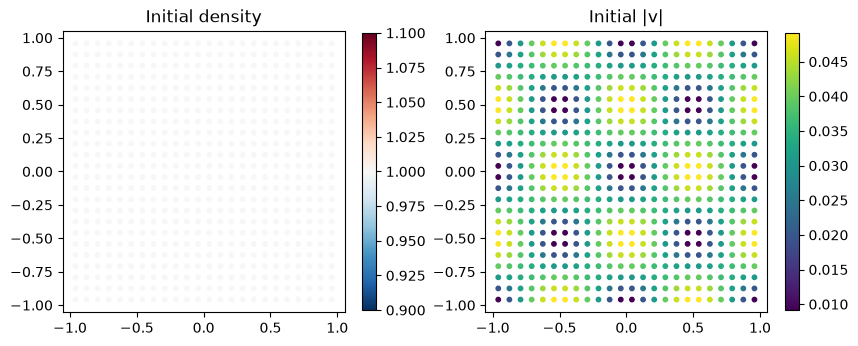

In [2]:
from warpSPH.sample.acousticCore import buildPeriodicVortexAcousticCoreSystem
from warpSPH.schemes.acousticCore import f_acoustic_core
from warpSPHCore import SupportScheme, buildVerletList
from warpSPHIntegrators import FixedPointSolver, JFNKSolver, get_reference_state, getIntegrator

NX = 24
_system, _config, schemeConfig = buildPeriodicVortexAcousticCoreSystem(nx=NX)
h = _system.state.supports.mean().item()
dtAcoustic = 0.2 * h / schemeConfig.soundSpeed  # dt_c = C*h/c_s, C=0.2
print(f'nx={NX} -> {_system.state.positions.shape[0]} particles, h={h:.4f}, '
     f'soundSpeed={schemeConfig.soundSpeed}, dt_acoustic={dtAcoustic:.5f}')

pos = _system.state.positions.cpu()
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
sc0 = axes[0].scatter(pos[:, 0], pos[:, 1], c=_system.state.densities.cpu(), cmap='RdBu_r', s=10)
axes[0].set_aspect('equal'); axes[0].set_title('Initial density')
fig.colorbar(sc0, ax=axes[0], shrink=0.8)
vmag = _system.state.velocities.norm(dim=1).cpu()
sc1 = axes[1].scatter(pos[:, 0], pos[:, 1], c=vmag, cmap='viridis', s=10)
axes[1].set_aspect('equal'); axes[1].set_title('Initial |v|')
fig.colorbar(sc1, ax=axes[1], shrink=0.8)
plt.show()

## Driving different solvers

Unlike the wave-equation `Case` notebook, there is no registered `Case` here
to drive through `runner.run(...)` — Phase B deliberately built this as a
standalone state/system pair, no `SchemeBundle`. So the step loop is
unrolled directly, the same pattern every `examples/*/0N-*.ipynb` notebook
in this repo uses when it needs to customize a per-step call
(`05-taylor-green-vortex.ipynb` is that pattern; the wave `Case` notebook
does the same thing one layer up).

Positions move here — unlike the wave equation's static-neighbor case — so
`runAcousticCore` below rebuilds the Verlet adjacency list once per real
step (not per DIRK/RK stage; the same "reuse the adjacency `f_acoustic_core`
was handed across every stage of one step" contract `f_wave_equation`
follows).

In [3]:
def runAcousticCore(integrationScheme, dt, nSteps, solver=None, nx=NX, rebuildAdjacencyEvery=1,
                    nSnapshots=5, divergeRhoMax=100.0):
    """Build a fresh `AcousticCoreSystem` and drive it for `nSteps` real
    steps. Stops early once the state is non-finite or `rho` exceeds
    `divergeRhoMax * rho0` -- a genuinely unstable run can take a variable
    number of further steps to literally overflow to inf/nan (GPU reduction
    order isn't bit-exact run to run), so this is a more robust stopping
    rule than waiting on that alone.

    Returns `(finalState, snapshots, trajectory, diverged)`:
      snapshots  -- list of (step, positions, densities) tuples, ~nSnapshots of them, CPU
      trajectory -- one dict per completed step: step, rhoMax, rhoStd, vMax
      diverged   -- True if the run stopped early
    """
    system, config, schemeConfig = buildPeriodicVortexAcousticCoreSystem(nx=nx, uMag = 0.5)
    scheme = getIntegrator(integrationScheme)
    kwargs = dict(f=f_acoustic_core, dt=dt, config=config, schemeConfig=schemeConfig, verbose=False)
    if solver is not None:
        kwargs['solver'] = solver

    snapEvery = max(1, nSteps // (nSnapshots - 1)) if nSnapshots > 1 else nSteps
    snapshots = [(0, system.state.positions.clone().cpu(), system.state.densities.clone().cpu(), system.state.velocities.clone().cpu())]
    trajectory = [dict(step=0, rhoMax=system.state.densities.abs().max().item(),
                       rhoStd=system.state.densities.std().item(),
                       vMax=system.state.velocities.norm(dim=1).max().item())]

    state = system
    diverged = False
    for i in range(1, nSteps + 1):
        result = scheme(state=state, **kwargs)
        state = result.state
        s = get_reference_state(state)
        rhoMax = s.densities.abs().max().item()
        rhoStd = s.densities.std().item()
        vMax = s.velocities.norm(dim=1).max().item()
        finite = math.isfinite(rhoMax) and math.isfinite(vMax)
        stillBounded = finite and rhoMax < divergeRhoMax * schemeConfig.restDensity
        trajectory.append(dict(step=i, rhoMax=rhoMax, rhoStd=rhoStd, vMax=vMax))
        if i % snapEvery == 0 or not stillBounded:
            snapshots.append((i, s.positions.clone().cpu(), s.densities.clone().cpu(), s.velocities.clone().cpu()))
        if not stillBounded:
            diverged = True
            break
        if i % rebuildAdjacencyEvery == 0:
            state.adjacency = buildVerletList(s, config.domain, 1.0, SupportScheme.SuperSymmetric, None)
    return state, snapshots, trajectory, diverged

# quick smoke test of every solver on one small step
for name, scheme_name, solver in [
    ('RK4', 'RK4', None),
    ('BE+Picard(2)', 'Backward Euler (implicit)', FixedPointSolver(iterations=2)),
    ('BE+JFNK(fd)', 'Backward Euler (implicit)', JFNKSolver(matvec='fd', gmres_maxiter=60)),
]:
    _, _, traj, div = runAcousticCore(scheme_name, dtAcoustic, 1, solver=solver, nSnapshots=1)
    print(f'{name:14s} step1: rhoMax={traj[-1]["rhoMax"]:.6f} vMax={traj[-1]["vMax"]:.6f} diverged={div}')

Module warpSPHCore.coreOperations.wp_divergence 74e335c load on device 'cuda:0' took 2.86 ms  (cached)
Module warpSPHCore.coreOperations.wp_gradient b715d73 load on device 'cuda:0' took 2.95 ms  (cached)
RK4            step1: rhoMax=1.000092 vMax=0.491570 diverged=False
BE+Picard(2)   step1: rhoMax=1.000186 vMax=0.491555 diverged=False
BE+JFNK(fd)    step1: rhoMax=1.000165 vMax=0.491631 diverged=False


## Same-`dt` correctness check

At the case's own acoustic-CFL-scaled `dt`, explicit `RK4` and implicit
`SDIRK2` + `JFNKSolver` should agree closely — both are solving the same
physics, just with different local truncation error. This isn't a proof of
correctness on its own (nothing here has a closed-form reference the way
the wave equation's standing wave does), but agreement at a `dt` where
*both* schemes are known-good is a real cross-check that JFNK's
generic `2N+N`-dimensional coupled `(x, v, \rho)` stage solve is landing on
the same physics as the explicit scheme, before pushing `dt` to where they
can no longer be compared directly.

In [4]:
T_STEPS_SMALL = 15

stateE, snapsE, trajE, divE = runAcousticCore('RK4', dtAcoustic, T_STEPS_SMALL)
stateI, snapsI, trajI, divI = runAcousticCore(
    'SDIRK2', dtAcoustic, T_STEPS_SMALL,
    solver=JFNKSolver(matvec='fd', tol=1e-6, max_iterations=15, gmres_maxiter=60))

print(f'RK4:          diverged={divE}, final rhoMax={trajE[-1]["rhoMax"]:.6f}, vMax={trajE[-1]["vMax"]:.6f}')
print(f'SDIRK2+JFNK:  diverged={divI}, final rhoMax={trajI[-1]["rhoMax"]:.6f}, vMax={trajI[-1]["vMax"]:.6f}')

relDiffV = abs(trajE[-1]['vMax'] - trajI[-1]['vMax']) / trajE[-1]['vMax']
print(f'relative difference in final vMax: {relDiffV:.2e}')

RK4:          diverged=False, final rhoMax=1.000645, vMax=0.495856
SDIRK2+JFNK:  diverged=False, final rhoMax=1.000675, vMax=0.495902
relative difference in final vMax: 9.23e-05


**What to expect**: agreement to a handful of significant figures — the
residual difference is genuine `O(dt)` truncation-error mismatch between a
1st/2nd-order implicit tableau and 4th-order explicit `RK4` at a shared
small `dt`, not a discrepancy in the physics.

## The payoff: `dt` past the acoustic CFL, zero dissipation

`modules/timestep/weaklyCompressible.py`'s own acoustic timestep term is
`dt_c = C·h/c_s` — no `|v|` anywhere in it, which is exactly what forces
`c_s` and `dt` into tension in the real scheme (`JFNK_PLAN.md` Phase C's
whole motivation). We push `dt` to `20×` that term and run all three solvers
for the same **number of steps** (not the same simulated time, since two of
them won't reach it) — **with every dissipation term at zero**, the actual
hypothesis under test, not just an easier version of the wave-equation
demo's "push `dt` past stability" trick.

dt_large = 0.13333 (20x the acoustic CFL dt)


RK4:          diverged=True at step 2, rhoMax=37475.140625
BE+Picard(2): diverged=True at step 3, rhoMax=13529999.0
BE+JFNK:      diverged=False at step 40, rhoMax=1.047525


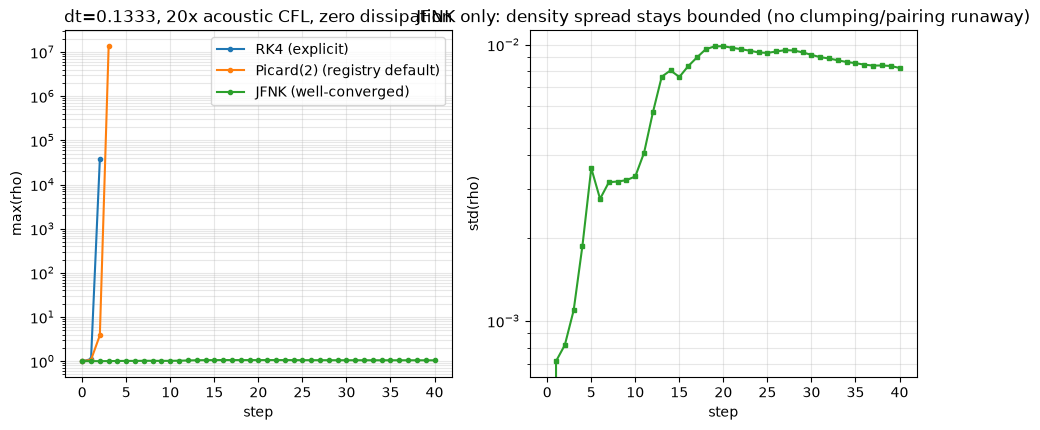

In [5]:
DT_LARGE = 20 * dtAcoustic
N_STEPS_LARGE = 40

print(f'dt_large = {DT_LARGE:.5f} ({DT_LARGE/dtAcoustic:.0f}x the acoustic CFL dt)')

stateEL, snapsEL, trajEL, divEL = runAcousticCore('RK4', DT_LARGE, N_STEPS_LARGE)
statePL, snapsPL, trajPL, divPL = runAcousticCore(
    'Backward Euler (implicit)', DT_LARGE, N_STEPS_LARGE, solver=FixedPointSolver(iterations=2))
stateJL, snapsJL, trajJL, divJL = runAcousticCore(
    'Backward Euler (implicit)', DT_LARGE, N_STEPS_LARGE,
    solver=JFNKSolver(matvec='fd', tol=1e-6, max_iterations=20, gmres_maxiter=60))

print(f'RK4:          diverged={divEL} at step {trajEL[-1]["step"]}, rhoMax={trajEL[-1]["rhoMax"]!s}')
print(f'BE+Picard(2): diverged={divPL} at step {trajPL[-1]["step"]}, rhoMax={trajPL[-1]["rhoMax"]!s}')
print(f'BE+JFNK:      diverged={divJL} at step {trajJL[-1]["step"]}, rhoMax={trajJL[-1]["rhoMax"]:.6f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
for label, traj in [('RK4 (explicit)', trajEL), ('Picard(2) (registry default)', trajPL), ('JFNK (well-converged)', trajJL)]:
    steps = [row['step'] for row in traj]
    rhoMax = [row['rhoMax'] if math.isfinite(row['rhoMax']) else np.nan for row in traj]
    ax1.semilogy(steps, rhoMax, 'o-', label=label, markersize=3)
ax1.set_xlabel('step'); ax1.set_ylabel('max(rho)')
ax1.set_title(f'dt={DT_LARGE:.4f}, {DT_LARGE/dtAcoustic:.0f}x acoustic CFL, zero dissipation')
ax1.legend(); ax1.grid(True, which='both', alpha=0.3)

stepsJ = [row['step'] for row in trajJL]
rhoStdJ = [row['rhoStd'] for row in trajJL]
ax2.semilogy(stepsJ, rhoStdJ, 's-', color=colors[2], markersize=3)
ax2.set_xlabel('step'); ax2.set_ylabel('std(rho)')
ax2.set_title('JFNK only: density spread stays bounded (no clumping/pairing runaway)')
ax2.grid(True, which='both', alpha=0.3)
plt.show()

**What to expect**: `RK4` and `Picard(2)` — the library's own shipped
default for every implicit DIRK scheme — both overflow to unphysical
densities within a handful of steps at this `dt` (float32 overflow follows
within a few more steps than that; exactly which step is not bit-exact run
to run, GPU reduction order, so the `runAcousticCore` helper's
`divergeRhoMax` threshold catches it robustly either way). `JFNKSolver`
stays within a fraction of a percent of `rho0` for the entire run, with
`std(rho)` settling into a small, non-growing band rather than climbing —
the "bounded energy, no secular drift" criterion `JFNK_PLAN.md` Phase B
step 4 calls for, not agreement with any closed-form curve (zero-viscosity
2D SPH has no decay curve to compare against; that's Phase D's *viscous*
TGV check, a different comparison).

**This is the actual finding, not assumed going in**: on this
periodic-vortex probe, the acoustic-CFL/stability tax explicit (and
under-converged-Picard) WCSPH pays is decoupled from whether artificial
dissipation is present, once the acoustic part is solved to convergence
rather than integrated explicitly or Picard-iterated a fixed couple of
times.

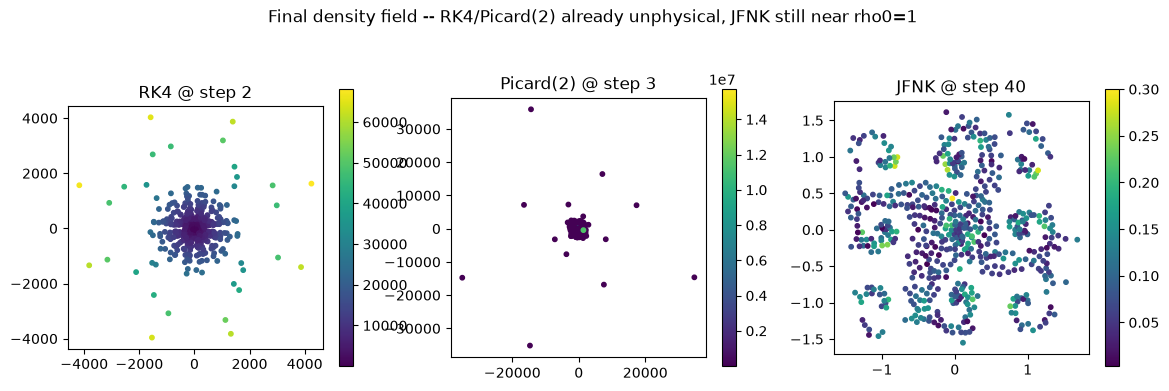

In [6]:
figS, axesS = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, (label, snaps) in zip(axesS, [('RK4', snapsEL), ('Picard(2)', snapsPL), ('JFNK', snapsJL)]):
    step, p, rho, vel = snaps[-1]
    rho_c = torch.nan_to_num(rho, nan=0.0, posinf=0.0, neginf=0.0)
    # sc = ax.scatter(p[:, 0], p[:, 1], c=rho_c, cmap='RdBu_r', s=10)
    sc = ax.scatter(p[:, 0], p[:, 1], c=torch.linalg.norm(vel, dim=1), cmap='viridis', s=10)
    ax.set_aspect('equal'); ax.set_title(f'{label} @ step {step}')
    figS.colorbar(sc, ax=ax, shrink=0.8)
plt.suptitle('Final density field -- RK4/Picard(2) already unphysical, JFNK still near rho0=1')
plt.show()

## What does the implicit solve cost?

Stability alone doesn't say whether pushing `dt` this far is a net win --
a JFNK stage solve that needs several Newton corrections, each several
GMRES iterations of `f_acoustic_core` evaluations, could easily cost more
per unit of *simulated time* than a few small `RK4` steps would. This
sweeps the `dt` multiplier from `1x` the acoustic CFL up past where
`Picard(2)` (the registry's own implicit default) destabilizes, timing
steady-state per-step cost for each -- the same `ms/step` / `ms/RHS` /
`f-evals/step` measures `benchmarks/wave/bench_performance.py` reports for
the wave equation, reproduced here with CUDA events since this notebook
doesn't import that suite's harness (matching its `StepTimer` pattern by
hand, the same "no `Case`/CLI machinery" choice the rest of this file
makes).

Only a handful of post-warmup steps per point (`N_STEPS_COST` below), not
the stability run's `40` -- steady-state per-step cost is visible in a
handful of steps, and the expensive end of this sweep (large `dt`, many
Newton/GMRES iterations per step) is exactly where a 40-step run would
cost the most wall-clock time for the least new information.

In [7]:
import time


class RecordingSolver:
    """Wraps a `NonlinearSolver` to record each stage solve's `SolveResult`
    (`converged`, `iterations`) -- the DIRK driver only reads `.y` off this
    and otherwise discards it, so without a wrapper a stage that silently
    used its full `max_iterations` budget without converging is
    indistinguishable, from the state alone, from one that converged in
    one. Structurally the same wrapper as `RecordingSolver` in
    `benchmarks/common/runner.py`, reproduced here (rather than imported)
    so this notebook keeps importing only from `warpSPH`/`warpSPHIntegrators`,
    matching the rest of the file.
    """

    def __init__(self, inner):
        self.inner = inner
        self.solves = 0
        self.converged = 0
        self.iterations = []

    def solve(self, step, y0, norm=None, **opts):
        result = self.inner.solve(step, y0, norm, **opts)
        self.solves += 1
        self.converged += int(bool(result.converged))
        self.iterations.append(int(result.iterations))
        return result

    def stats(self):
        iters = [i for i in self.iterations if math.isfinite(i)]
        return dict(solves=self.solves, converged=self.converged,
                    itersMean=(sum(iters) / len(iters)) if iters else None)


def timeAcousticCoreRun(integrationScheme, dt, nSteps, solver=None, nx=NX,
                        rebuildAdjacencyEvery=1, divergeRhoMax=100.0, warmupSteps=2):
    """Like `runAcousticCore`, but times post-warmup steady-state per-step
    cost (CUDA events on GPU, `time.perf_counter` on CPU) and counts real
    `f_acoustic_core` evaluations -- the fair cross-scheme cost measure: a
    JFNK step hides one extra RHS evaluation per Newton correction's GMRES
    iteration inside what looks like a single "step" (`bench_performance.py`'s
    `ms/RHS` reasoning, unchanged here). No snapshots/trajectory -- this is
    a cost probe, use `runAcousticCore` for the stability trajectory.

    Returns a dict: `diverged`, `stepsDone`, `finalRhoMax`, `msPerStep`,
    `msPerRhs`, `fEvalsPerStep`, and (when `solver` is given) `solves`,
    `converged`, `itersMean` from the wrapped solver's own `SolveResult`s.
    """
    system, config, schemeConfig = buildPeriodicVortexAcousticCoreSystem(nx=nx, uMag=0.5)
    device = system.state.positions.device
    useCuda = device.type == 'cuda' and torch.cuda.is_available()
    scheme = getIntegrator(integrationScheme)

    count = [0]
    def fCounted(*args, **kwargs):
        count[0] += 1
        return f_acoustic_core(*args, **kwargs)

    recorder = RecordingSolver(solver) if solver is not None else None
    kwargs = dict(f=fCounted, dt=dt, config=config, schemeConfig=schemeConfig, verbose=False)
    if recorder is not None:
        kwargs['solver'] = recorder

    state = system
    diverged = False
    stepsDone = 0
    stepMs = 0.0
    rhoMax = schemeConfig.restDensity

    for i in range(warmupSteps + nSteps):
        timed = i >= warmupSteps
        if timed and useCuda:
            begin = torch.cuda.Event(enable_timing=True)
            end = torch.cuda.Event(enable_timing=True)
            begin.record()
        elif timed:
            t0 = time.perf_counter()

        result = scheme(state=state, **kwargs)

        if timed:
            if useCuda:
                end.record()
                torch.cuda.synchronize()
                stepMs += begin.elapsed_time(end)
            else:
                stepMs += (time.perf_counter() - t0) * 1000.0

        state = result.state
        s = get_reference_state(state)
        rhoMax = s.densities.abs().max().item()
        stepsDone = i + 1
        stillBounded = math.isfinite(rhoMax) and rhoMax < divergeRhoMax * schemeConfig.restDensity
        if not stillBounded:
            diverged = True
            break
        if i % rebuildAdjacencyEvery == 0:
            state.adjacency = buildVerletList(s, config.domain, 1.0, SupportScheme.SuperSymmetric, None)

    timedSteps = max(0, stepsDone - warmupSteps)
    fEvalsPerStep = count[0] / max(1, stepsDone)
    out = dict(diverged=diverged, stepsDone=stepsDone, finalRhoMax=rhoMax,
              msPerStep=(stepMs / timedSteps) if timedSteps > 0 else float('nan'),
              fEvalsPerStep=fEvalsPerStep)
    out['msPerRhs'] = out['msPerStep'] / fEvalsPerStep if fEvalsPerStep > 0 else float('nan')
    if recorder is not None:
        out.update(recorder.stats())
    return out


N_STEPS_COST = 8
WARMUP_STEPS_COST = 2

rk4Ref = timeAcousticCoreRun('RK4', dtAcoustic, N_STEPS_COST, warmupSteps=WARMUP_STEPS_COST)
print(f"RK4 @ 1x acoustic CFL (reference): {rk4Ref['msPerStep']:.2f} ms/step, "
     f"{rk4Ref['fEvalsPerStep']:.0f} f-eval/step, diverged={rk4Ref['diverged']}")

RK4 @ 1x acoustic CFL (reference): 2.87 ms/step, 4 f-eval/step, diverged=False


In [8]:
DT_MULTIPLIERS = [1, 2, 5, 10, 20, 30, 50, 80, 120]

picardRecords = []
jfnkRecords = []
picardDiverged = False

for mult in DT_MULTIPLIERS:
    dt = mult * dtAcoustic

    if not picardDiverged:
        recP = timeAcousticCoreRun('Backward Euler (implicit)', dt, N_STEPS_COST,
                                   solver=FixedPointSolver(iterations=2),
                                   warmupSteps=WARMUP_STEPS_COST)
        recP['dtMultiplier'] = mult
        picardRecords.append(recP)
        status = f"DIVERGED @ step {recP['stepsDone']}" if recP['diverged'] else 'stable'
        print(f"Picard(2)  {mult:4d}x  {recP['msPerStep']:8.2f} ms/step  "
             f"{recP['msPerRhs']:6.3f} ms/RHS  {recP['fEvalsPerStep']:4.1f} f/step  {status}")
        picardDiverged = recP['diverged']

    recJ = timeAcousticCoreRun('Backward Euler (implicit)', dt, N_STEPS_COST,
                               solver=JFNKSolver(matvec='fd', tol=1e-6, max_iterations=20, gmres_maxiter=60),
                               warmupSteps=WARMUP_STEPS_COST)
    recJ['dtMultiplier'] = mult
    jfnkRecords.append(recJ)
    itersStr = f"{recJ['itersMean']:.1f}" if recJ.get('itersMean') is not None else '-'
    status = f"DIVERGED @ step {recJ['stepsDone']}" if recJ['diverged'] else 'stable'
    print(f"JFNK       {mult:4d}x  {recJ['msPerStep']:8.2f} ms/step  "
         f"{recJ['msPerRhs']:6.3f} ms/RHS  {recJ['fEvalsPerStep']:4.1f} f/step  "
         f"newtonIters~{itersStr:>4s}  {status}")
    if recJ['diverged']:
        break

Picard(2)     1x      1.58 ms/step   0.791 ms/RHS   2.0 f/step  stable
JFNK          1x     13.75 ms/step   1.091 ms/RHS  12.6 f/step  newtonIters~ 3.1  stable


Picard(2)     2x      1.54 ms/step   0.769 ms/RHS   2.0 f/step  stable


JFNK          2x     23.93 ms/step   1.129 ms/RHS  21.2 f/step  newtonIters~ 4.7  stable
Picard(2)     5x      1.51 ms/step   0.754 ms/RHS   2.0 f/step  DIVERGED @ step 7


JFNK          5x     80.34 ms/step   1.255 ms/RHS  64.0 f/step  newtonIters~ 8.1  stable


JFNK         10x    279.32 ms/step   1.641 ms/RHS  170.2 f/step  newtonIters~ 6.9  stable


JFNK         20x    762.09 ms/step   1.900 ms/RHS  401.0 f/step  newtonIters~ 8.3  stable


JFNK         30x   1218.69 ms/step   1.856 ms/RHS  656.6 f/step  newtonIters~11.6  stable


JFNK         50x    259.42 ms/step   1.712 ms/RHS  151.6 f/step  newtonIters~ 3.4  DIVERGED @ step 7


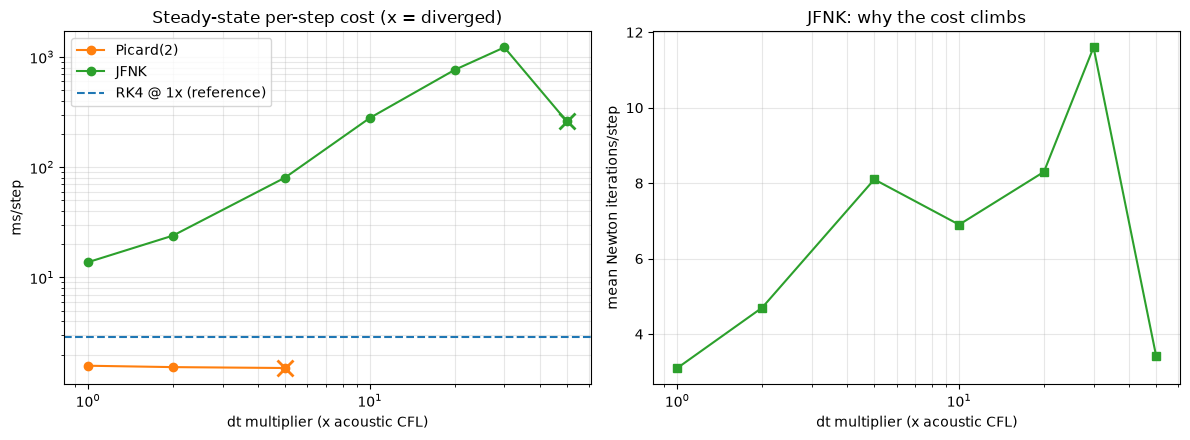

In [9]:
fig, (axCost, axIters) = plt.subplots(1, 2, figsize=(12, 4.5))

multsP = [r['dtMultiplier'] for r in picardRecords]
costP = [r['msPerStep'] for r in picardRecords]
axCost.plot(multsP, costP, 'o-', label='Picard(2)', color=colors[1])
if picardRecords and picardRecords[-1]['diverged']:
    axCost.plot(multsP[-1], costP[-1], 'x', color=colors[1], markersize=12, markeredgewidth=2)

multsJ = [r['dtMultiplier'] for r in jfnkRecords]
costJ = [r['msPerStep'] for r in jfnkRecords]
axCost.plot(multsJ, costJ, 'o-', label='JFNK', color=colors[2])
if jfnkRecords and jfnkRecords[-1]['diverged']:
    axCost.plot(multsJ[-1], costJ[-1], 'x', color=colors[2], markersize=12, markeredgewidth=2)

axCost.axhline(rk4Ref['msPerStep'], color=colors[0], linestyle='--', label='RK4 @ 1x (reference)')
axCost.set_xscale('log'); axCost.set_yscale('log')
axCost.set_xlabel('dt multiplier (x acoustic CFL)'); axCost.set_ylabel('ms/step')
axCost.set_title('Steady-state per-step cost (x = diverged)')
axCost.legend(); axCost.grid(True, which='both', alpha=0.3)

itersJ = [r['itersMean'] for r in jfnkRecords if r.get('itersMean') is not None]
multsJi = [r['dtMultiplier'] for r in jfnkRecords if r.get('itersMean') is not None]
axIters.plot(multsJi, itersJ, 's-', color=colors[2])
axIters.set_xscale('log')
axIters.set_xlabel('dt multiplier (x acoustic CFL)'); axIters.set_ylabel('mean Newton iterations/step')
axIters.set_title('JFNK: why the cost climbs')
axIters.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

**What to expect**: `Picard(2)`'s per-step cost should be flat and cheap
(a fixed 2 RHS evaluations/step, independent of `dt`) right up until it
diverges -- its cost story is simple because it never adapts to the
problem. `JFNK`'s `ms/step` should climb with the `dt` multiplier as the
Newton/GMRES loop needs more corrections to drive the stiffer stage
equation to `tol`; `ms/RHS` is the fairer per-unit-work number and should
stay much flatter than `ms/step` (one GPU kernel launch of `f_acoustic_core`
costs about the same regardless of how many the solver ends up needing).
Where `JFNK` is still cheap in absolute terms and `Picard(2)` can't run at
all is the clean "worth it" regime; where `JFNK`'s cost has climbed to
rival just taking several small `RK4` steps instead is the point this
`dt` multiplier stops being a win even though it is still *stable* --
those are two different questions, and this sweep is what tells them
apart.

## Caveats, stated plainly

This is one probe — one resolution (`nx=24`), one `dt` multiplier (`20×`),
one initial condition (a periodic vortex), one run length (`40` steps ≈
several vortex periods at this `dt`). It demonstrates the *acoustic
stiffness* half of the hypothesis cleanly: a well-converged implicit solve
survives where explicit time integration and under-converged Picard
iteration both fail, with zero dissipation. It does **not** demonstrate
that zero-dissipation WCSPH never destabilizes at any resolution, duration,
or initial condition — and it says nothing about the *tensile/pairing*
instability particle shifting (deliberately not built into this rudimentary
core) normally guards against, which is a spatial-discretization concern
time integration doesn't touch either way (`JFNK_PLAN.md`'s own note on
this). A longer run at higher resolution, and eventually the real
`deltaSPH_step` acoustic subsystem (Phase C/D), are the next things to
check this against.

The cost sweep above carries the same single-probe caveat: one resolution
(`nx=24`), one solver-budget choice (`tol=1e-6`, `max_iterations=20`,
`gmres_maxiter=60`) held fixed across the whole `dt` sweep. Cost at higher
resolution isn't measured here — GMRES's own cost per iteration grows with
problem size, so the `ms/step` curve above shouldn't be assumed to hold at,
say, `nx=128`; extending `bench_performance.py`'s nx-sweep pattern (already
built for the wave equation) to `f_acoustic_core` is the natural next step
for that question.

## Reference

```python
from warpSPH.sample.acousticCore import buildPeriodicVortexAcousticCoreSystem
from warpSPH.schemes.acousticCore import f_acoustic_core
from warpSPHIntegrators import JFNKSolver, get_reference_state, getIntegrator

system, config, schemeConfig = buildPeriodicVortexAcousticCoreSystem(nx=24)
scheme = getIntegrator('Backward Euler (implicit)')   # or any registered DIRK name
result = scheme(state=system, dt=0.13, f=f_acoustic_core, config=config,
                schemeConfig=schemeConfig, solver=JFNKSolver(matvec='fd', gmres_maxiter=60))
get_reference_state(result.state)  # the new AcousticCoreState
```

No `Case`/CLI wraps this (yet) — `f_acoustic_core`/`buildPeriodicVortexAcousticCoreSystem`
are imported directly from their submodules, matching how the wave-equation
implicit test/notebooks already use `f_wave_equation`. See `JFNK_PLAN.md`
Phase B for the full writeup, and `warpSPH/tests/test_acousticCore.py` /
`test_acousticCoreStability.py` for the pytest version of everything above.